In [ ]:
!pip install -q statsmodels

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import time
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import jarque_bera

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance

import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.max_columns", 300)
np.random.seed(42)

In [ ]:
DATA_TRAIN_PATH = "data_train.csv"
TARGET_TRAIN_PATH = "target_train.csv"
DATA_TEST_PATH = "data_test_small.csv"
TARGET_TEST_PATH = "target_test_small.csv"

data_train = pd.read_csv(DATA_TRAIN_PATH, parse_dates=["datetime"])
target_train = pd.read_csv(TARGET_TRAIN_PATH, parse_dates=["Дата"])
data_test = pd.read_csv(DATA_TEST_PATH, parse_dates=["datetime"])
target_test = pd.read_csv(TARGET_TEST_PATH, parse_dates=["Дата"])

print("data_train:", data_train.shape)
print("target_train:", target_train.shape)
print("data_test_small:", data_test.shape)
print("target_test_small:", target_test.shape)

display(data_train.head())
display(target_train.head())

data_train: (319546, 17)
target_train: (1773, 2)
data_test_small: (39943, 17)
target_test_small: (318, 2)


,datetime,telemetry_0,telemetry_1,telemetry_2,telemetry_3,telemetry_4,telemetry_5,telemetry_6,telemetry_7,telemetry_8,telemetry_9,telemetry_10,telemetry_11,telemetry_12,telemetry_13,telemetry_14,telemetry_15
0,2019-03-01 00:01:00,0.737538,0.478367,0.292816,0.644016,0.919471,0.884814,0.754800,0.413295,0.47192,0.677801,0.687535,0.498407,NaN,NaN,NaN,NaN
1,2019-03-01 00:02:00,0.738406,0.478977,0.292816,0.648557,0.919471,0.887129,0.752977,0.413295,0.47192,0.677801,0.688926,0.498407,NaN,NaN,NaN,NaN
2,2019-03-01 00:03:00,0.738985,0.478977,0.292816,0.647164,0.919471,0.887129,0.755444,0.413295,0.47192,0.677801,0.690316,0.498407,NaN,NaN,NaN,NaN
3,2019-03-01 00:04:00,0.739563,0.478977,0.292816,0.636938,0.919471,0.887129,0.754800,0.413295,0.47192,0.678079,0.692820,0.498407,NaN,NaN,NaN,NaN
4,2019-03-01 00:05:00,0.740431,0.477119,0.292816,0.635834,0.919471,0.887707,0.754156,0.413295,0.47192,0.678357,0.695601,0.498407,NaN,NaN,NaN,NaN


,Дата,target
0,2019-03-13 17:00:00,0.123711
1,2019-03-13 21:00:00,0.319588
2,2019-03-14 01:00:00,0.255155
3,2019-03-14 05:00:00,0.319588
4,2019-03-14 09:00:00,0.159794


In [ ]:
def preprocess_telemetry(df: pd.DataFrame, sparse_threshold: float = 0.95):
    df = df.copy()
    df["datetime"] = pd.to_datetime(df["datetime"])

    # В данных есть дубликаты минутных отметок.
    # Для промышленного процесса корректно агрегировать их как среднее за минуту.
    df = df.groupby("datetime", as_index=False).mean(numeric_only=True).sort_values("datetime")

    missing_share = df.isna().mean()
    drop_cols = missing_share[missing_share > sparse_threshold].index.tolist()
    drop_cols = [c for c in drop_cols if c != "datetime"]

    df = df.drop(columns=drop_cols).copy()

    feature_cols = [c for c in df.columns if c != "datetime"]

    # Оставшиеся редкие пропуски заполняем вперед/назад,
    # так как телеметрия описывает непрерывный технологический процесс.
    df[feature_cols] = df[feature_cols].ffill().bfill()

    return df, drop_cols, missing_share


def preprocess_target(df: pd.DataFrame):
    df = df.copy()
    df = df.rename(columns={"Дата": "datetime"}).sort_values("datetime").reset_index(drop=True)
    return df


def summarize_time_grid(df: pd.DataFrame, time_col: str):
    diffs = df[time_col].sort_values().diff().dropna()
    return {
        "rows": len(df),
        "min_dt": df[time_col].min(),
        "max_dt": df[time_col].max(),
        "duplicates": int(df.duplicated(subset=[time_col]).sum()),
        "top_intervals": diffs.value_counts().head(10)
    }


def estimate_delay_profile(telemetry_df: pd.DataFrame, target_df: pd.DataFrame, max_delay_min: int = 20):
    # Проверяем разные задержки отбора пробы:
    # сдвигаем лабораторный замер назад на 0..20 минут
    # и смотрим, при каком сдвиге связь с телеметрией strongest.
    scores = []
    feature_cols = [c for c in telemetry_df.columns if c != "datetime"]

    telem_sorted = telemetry_df.sort_values("datetime")
    target_sorted = target_df.sort_values("datetime").copy()

    for delay in range(max_delay_min + 1):
        tmp = target_sorted.copy()
        tmp["sample_time"] = tmp["datetime"] - pd.Timedelta(minutes=delay)

        merged = pd.merge_asof(
            tmp.sort_values("sample_time"),
            telem_sorted,
            left_on="sample_time",
            right_on="datetime",
            direction="backward",
            tolerance=pd.Timedelta("1min")
        )

        corr = merged[feature_cols + ["target"]].corr(numeric_only=True)["target"].drop("target")
        score = corr.abs().sort_values(ascending=False).head(5).mean()
        scores.append((delay, score))

    delay_profile = pd.DataFrame(scores, columns=["delay_min", "score"])
    best_delay = int(delay_profile.sort_values("score", ascending=False).iloc[0]["delay_min"])
    return best_delay, delay_profile


def create_time_features(df: pd.DataFrame):
    df = df.copy()
    df["hour"] = df["datetime"].dt.hour
    df["dayofweek"] = df["datetime"].dt.dayofweek

    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

    df["dow_sin"] = np.sin(2 * np.pi * df["dayofweek"] / 7)
    df["dow_cos"] = np.cos(2 * np.pi * df["dayofweek"] / 7)
    return df


def create_lag_rolling_features(df: pd.DataFrame, telemetry_cols, lags=(1, 5, 15, 30, 60), windows=(5, 15, 30, 60)):
    df = df.copy()

    for col in telemetry_cols:
        for lag in lags:
            df[f"{col}_lag_{lag}"] = df[col].shift(lag)

        df[f"{col}_diff_1"] = df[col].diff(1)
        df[f"{col}_diff_5"] = df[col].diff(5)

        for window in windows:
            roll = df[col].rolling(window=window, min_periods=window)
            df[f"{col}_roll_mean_{window}"] = roll.mean()
            df[f"{col}_roll_std_{window}"] = roll.std()
            df[f"{col}_roll_min_{window}"] = roll.min()
            df[f"{col}_roll_max_{window}"] = roll.max()

    return df


def build_supervised_dataset(feature_df: pd.DataFrame, target_df: pd.DataFrame, delay_min: int = 0):
    target_df = target_df.copy()
    target_df["effective_time"] = target_df["datetime"] - pd.Timedelta(minutes=delay_min)

    merged = pd.merge_asof(
        target_df.sort_values("effective_time"),
        feature_df.sort_values("datetime"),
        left_on="effective_time",
        right_on="datetime",
        direction="backward",
        tolerance=pd.Timedelta("1min")
    )

    merged = merged.drop(columns=["effective_time"])
    return merged


def safe_mape(y_true, y_pred, eps=1e-6):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps))) * 100


def wape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100


def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def direction_accuracy(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    true_diff = np.sign(np.diff(y_true))
    pred_diff = np.sign(np.diff(y_pred))

    mask = true_diff != 0
    if mask.sum() == 0:
        return np.nan

    return (true_diff[mask] == pred_diff[mask]).mean() * 100


def evaluate_predictions(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "MAPE_%": safe_mape(y_true, y_pred),
        "WAPE_%": wape(y_true, y_pred),
        "Direction_Accuracy_%": direction_accuracy(y_true, y_pred),
    }


@dataclass
class OLSArtifacts:
    model: object
    imputer: object
    selector: object
    selected_columns: list


def fit_ols_with_selection(X_train: pd.DataFrame, y_train: pd.Series, k_best: int = 25):
    imputer = SimpleImputer(strategy="median")
    X_train_imp = imputer.fit_transform(X_train)

    selector = SelectKBest(score_func=f_regression, k=min(k_best, X_train.shape[1]))
    X_train_sel = selector.fit_transform(X_train_imp, y_train)

    selected_columns = X_train.columns[selector.get_support()].tolist()

    X_train_sel_df = pd.DataFrame(X_train_sel, columns=selected_columns, index=X_train.index)
    X_train_sel_df = sm.add_constant(X_train_sel_df, has_constant="add")

    model = sm.OLS(y_train, X_train_sel_df).fit()

    artifacts = OLSArtifacts(
        model=model,
        imputer=imputer,
        selector=selector,
        selected_columns=selected_columns
    )
    return artifacts


def predict_ols(artifacts: OLSArtifacts, X: pd.DataFrame):
    X_imp = artifacts.imputer.transform(X)
    X_sel = artifacts.selector.transform(X_imp)
    X_sel_df = pd.DataFrame(X_sel, columns=artifacts.selected_columns, index=X.index)
    X_sel_df = sm.add_constant(X_sel_df, has_constant="add")
    return artifacts.model.predict(X_sel_df)


def residual_diagnostics(y_true, y_pred):
    residuals = np.asarray(y_true) - np.asarray(y_pred)

    jb_stat, jb_p = jarque_bera(residuals)
    lb_df = acorr_ljungbox(residuals, lags=[10], return_df=True)

    diag = pd.DataFrame({
        "test": ["Jarque-Bera", "Ljung-Box (lag=10)"],
        "statistic": [jb_stat, float(lb_df["lb_stat"].iloc[0])],
        "p_value": [jb_p, float(lb_df["lb_pvalue"].iloc[0])]
    })

    return diag, residuals

## 3. EDA и синхронизация источников

In [ ]:
train_telem, dropped_train_cols, train_missing_share = preprocess_telemetry(data_train)
test_telem_raw, _, test_missing_share = preprocess_telemetry(data_test)

common_cols = [c for c in train_telem.columns if c in test_telem_raw.columns]
test_telem = test_telem_raw[common_cols].copy()

train_target = preprocess_target(target_train)
test_target = preprocess_target(target_test)

print("Удалённые почти пустые признаки:", dropped_train_cols)

print("\nСводка по data_train:")
for k, v in summarize_time_grid(data_train, "datetime").items():
    print(k, "\n", v, "\n")

print("\nСводка по target_train:")
for k, v in summarize_time_grid(train_target, "datetime").items():
    print(k, "\n", v, "\n")

Удалённые почти пустые признаки: ['telemetry_12', 'telemetry_13', 'telemetry_14', 'telemetry_15']

Сводка по data_train:
rows 
 319546 

min_dt 
 2019-03-01 00:01:00 

max_dt 
 2019-10-07 19:58:00 

duplicates 
 1548 

top_intervals 
 datetime
0 days 00:01:00    317997
0 days 00:00:00      1548
Name: count, dtype: int64 


Сводка по target_train:
rows 
 1773 

min_dt 
 2019-03-13 17:00:00 

max_dt 
 2019-10-07 21:00:00 

duplicates 
 0 

top_intervals 
 datetime
0 days 02:00:00     1570
0 days 04:00:00      184
0 days 01:00:00        4
0 days 07:00:00        2
18 days 08:30:00       1
0 days 11:00:00        1
0 days 14:00:00        1
0 days 01:30:00        1
9 days 06:00:00        1
9 days 14:00:00        1
Name: count, dtype: int64 



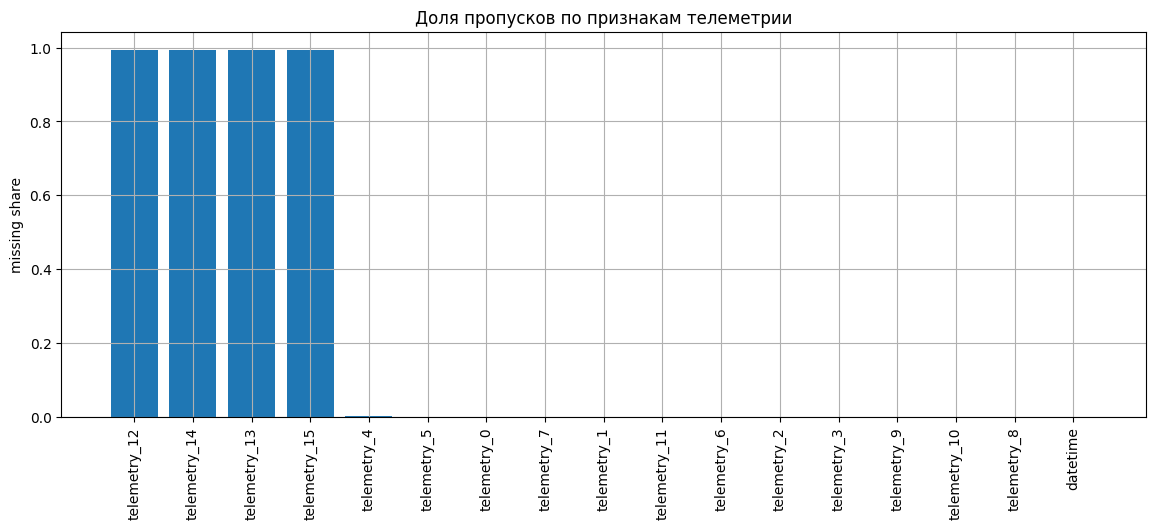

In [ ]:
# Доля пропусков
train_missing = train_missing_share.sort_values(ascending=False)

plt.figure(figsize=(14, 5))
plt.bar(train_missing.index, train_missing.values)
plt.xticks(rotation=90)
plt.title("Доля пропусков по признакам телеметрии")
plt.ylabel("missing share")
plt.show()

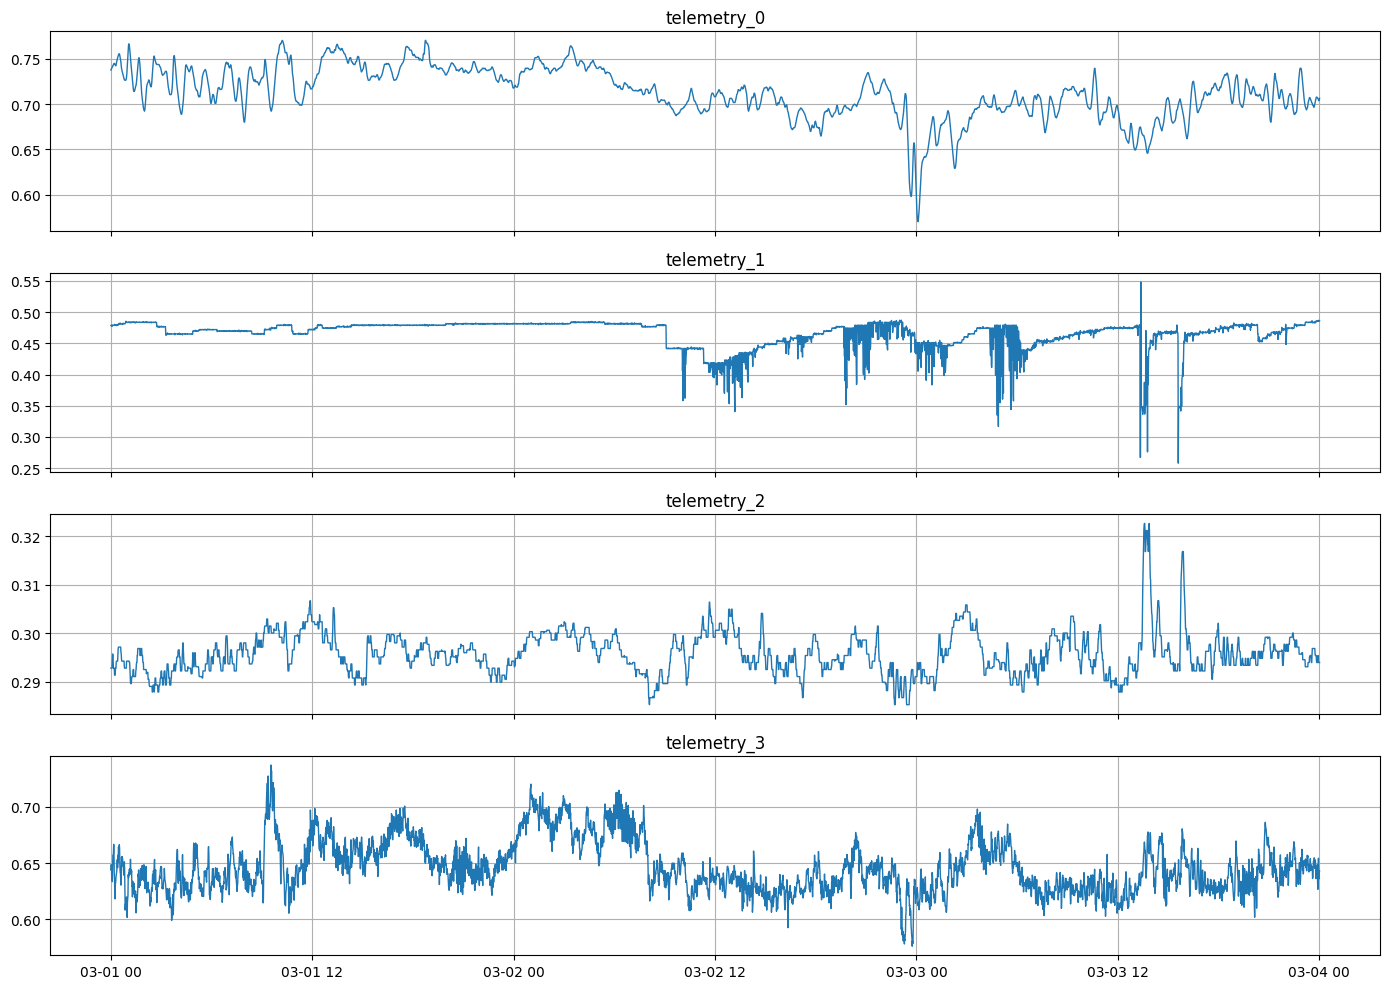

In [ ]:
# Фрагмент телеметрии на коротком окне
sample_start = train_telem["datetime"].min()
sample_end = sample_start + pd.Timedelta(days=3)

sample = train_telem[(train_telem["datetime"] >= sample_start) & (train_telem["datetime"] <= sample_end)]
plot_cols = [c for c in train_telem.columns if c.startswith("telemetry_")][:4]

fig, axes = plt.subplots(len(plot_cols), 1, figsize=(14, 10), sharex=True)

for ax, col in zip(axes, plot_cols):
    ax.plot(sample["datetime"], sample[col], linewidth=1)
    ax.set_title(col)

plt.tight_layout()
plt.show()

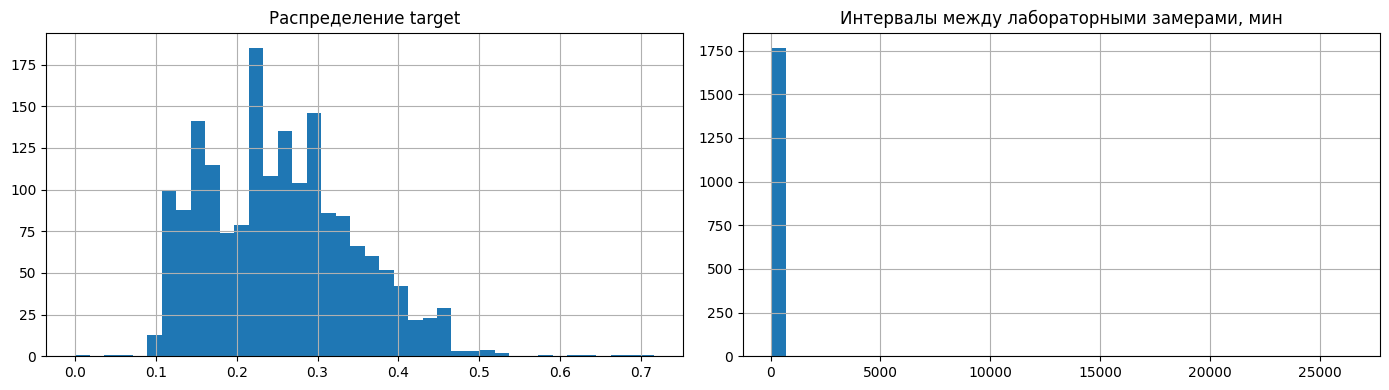

count     1772.000000
mean       169.164786
std        784.088290
min         60.000000
25%        120.000000
50%        120.000000
75%        120.000000
max      26430.000000
Name: datetime, dtype: float64


In [ ]:
# Распределение target и частота лабораторных замеров
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(train_target["target"], bins=40)
axes[0].set_title("Распределение target")

target_gaps_min = train_target["datetime"].diff().dropna().dt.total_seconds() / 60

axes[1].hist(target_gaps_min, bins=40)
axes[1].set_title("Интервалы между лабораторными замерами, мин")

plt.tight_layout()
plt.show()

print(target_gaps_min.describe())

Лучшая задержка: 18 мин


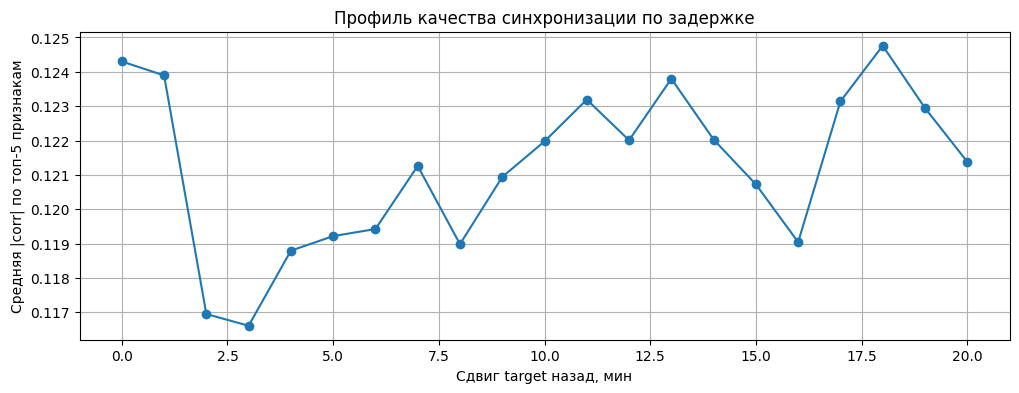

In [ ]:
# Проверка задержки между временем телеметрии и лабораторным замером
best_delay, delay_profile = estimate_delay_profile(train_telem, train_target, max_delay_min=20)

print("Лучшая задержка:", best_delay, "мин")

plt.figure(figsize=(12, 4))
plt.plot(delay_profile["delay_min"], delay_profile["score"], marker="o")
plt.title("Профиль качества синхронизации по задержке")
plt.xlabel("Сдвиг target назад, мин")
plt.ylabel("Средняя |corr| по топ-5 признакам")
plt.show()

,corr_with_target
telemetry_0,-0.176323
telemetry_3,-0.134250
telemetry_9,-0.117414
telemetry_8,0.107805
telemetry_11,-0.088010
telemetry_6,-0.085683
telemetry_10,-0.071960
telemetry_5,-0.067602
telemetry_4,-0.066271
telemetry_1,-0.043075


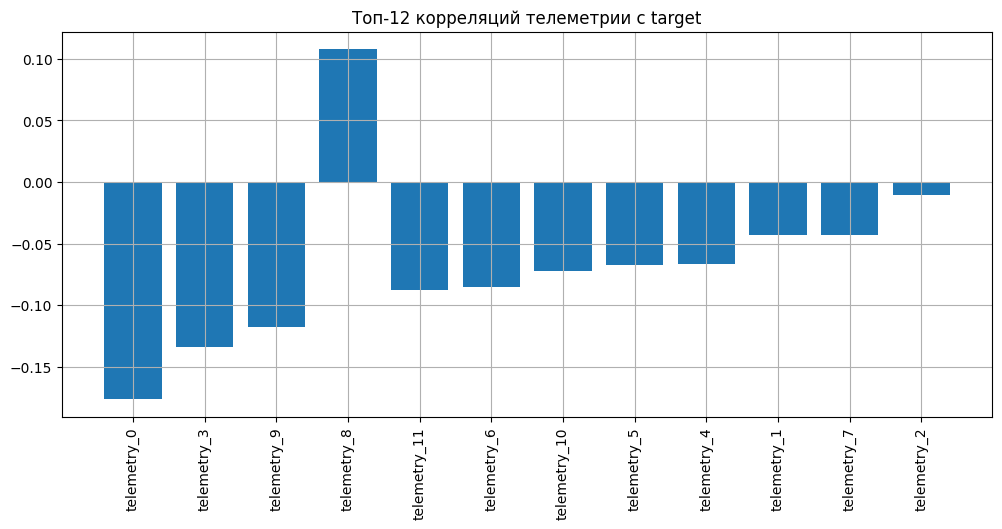

In [ ]:
# Корреляции телеметрии с target после синхронизации
eda_supervised = build_supervised_dataset(train_telem, train_target, delay_min=best_delay)
eda_supervised = eda_supervised.dropna()

corr_with_target = (
    eda_supervised[[c for c in eda_supervised.columns if c.startswith("telemetry_")] + ["target"]]
    .corr(numeric_only=True)["target"]
    .drop("target")
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

display(corr_with_target.head(12).to_frame("corr_with_target"))

plt.figure(figsize=(12, 5))
top_corr = corr_with_target.head(12)
plt.bar(top_corr.index, top_corr.values)
plt.xticks(rotation=90)
plt.title("Топ-12 корреляций телеметрии с target")
plt.show()

Вывод по EDA.
Телеметрия является почти непрерывным минутным рядом, однако содержит дубликаты временных отметок, которые были агрегированы по среднему значению за минуту. Четыре признака (telemetry_12–telemetry_15) оказались практически полностью пустыми и были исключены. Лабораторные измерения целевой переменной редкие и нерегулярные, в основном поступают раз в 2 часа. Для корректного обучения модели выполнена синхронизация телеметрии и лабораторных замеров через merge_asof с учётом проверяемой временной задержки отбора пробы.

## 4. Инжиниринг признаков для временных рядов

In [ ]:
telemetry_cols = [c for c in train_telem.columns if c.startswith("telemetry_")]

train_feat = create_time_features(train_telem)
test_feat = create_time_features(test_telem)

train_feat = create_lag_rolling_features(train_feat, telemetry_cols)
test_feat = create_lag_rolling_features(test_feat, telemetry_cols)

print("train_feat shape:", train_feat.shape)
print("test_feat shape:", test_feat.shape)

train_feat shape: (317998, 295)
test_feat shape: (39747, 295)


In [ ]:
train_supervised = build_supervised_dataset(train_feat, train_target, delay_min=best_delay)
test_supervised = build_supervised_dataset(test_feat, test_target, delay_min=best_delay)

train_supervised = train_supervised.dropna().reset_index(drop=True)
test_supervised = test_supervised.dropna().reset_index(drop=True)

feature_cols = [c for c in train_supervised.columns if c not in ["datetime_x", "datetime_y", "target"]]
feature_cols = [c for c in feature_cols if not c.startswith("datetime")]

X_all = train_supervised[feature_cols].copy()
y_all = train_supervised["target"].copy()

X_test_holdout = test_supervised[feature_cols].copy()
y_test_holdout = test_supervised["target"].copy()

print("Размер train supervised:", X_all.shape)
print("Размер holdout test supervised:", X_test_holdout.shape)

Размер train supervised: (1772, 294)
Размер holdout test supervised: (318, 294)


In [ ]:
# Временной split: первые 80% на обучение, последние 20% на validation
split_idx = int(len(train_supervised) * 0.8)

X_train = X_all.iloc[:split_idx].copy()
y_train = y_all.iloc[:split_idx].copy()

X_valid = X_all.iloc[split_idx:].copy()
y_valid = y_all.iloc[split_idx:].copy()

print("Train:", X_train.shape, y_train.shape)
print("Valid:", X_valid.shape, y_valid.shape)

Train: (1417, 294) (1417,)
Valid: (355, 294) (355,)


Вывод по инженерии признаков.
Для описания динамики процесса были сформированы лаговые признаки, скользящие статистики, разности и календарные признаки. Такой набор позволяет модели учитывать как текущее состояние печи, так и краткосрочную историю изменения режима, что особенно важно для инерционного промышленного процесса.

## 5. Построение прогнозных моделей

In [ ]:
ols_start = time.time()
ols_artifacts = fit_ols_with_selection(X_train, y_train, k_best=25)
ols_train_time = time.time() - ols_start

ols_valid_pred = predict_ols(ols_artifacts, X_valid)
ols_valid_metrics = evaluate_predictions(y_valid, ols_valid_pred)

ols_test_pred = predict_ols(ols_artifacts, X_test_holdout)
ols_test_metrics = evaluate_predictions(y_test_holdout, ols_test_pred)

print("OLS AIC:", ols_artifacts.model.aic)
print("OLS BIC:", ols_artifacts.model.bic)

display(pd.DataFrame([ols_valid_metrics]).round(4))
display(pd.DataFrame([ols_test_metrics]).round(4))

OLS AIC: -2780.1990024346287
OLS BIC: -2643.535274202671


,MAE,RMSE,MAPE_%,WAPE_%,Direction_Accuracy_%
0,0.0786,0.0951,45.9885,34.7825,51.9403


,MAE,RMSE,MAPE_%,WAPE_%,Direction_Accuracy_%
0,0.0799,0.0945,47.6821,38.1035,49.1694


In [ ]:
rf_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("selector", SelectKBest(score_func=f_regression, k=min(60, X_train.shape[1]))),
    ("model", RandomForestRegressor(
        n_estimators=150,
        max_depth=10,
        min_samples_leaf=5,
        n_jobs=-1,
        random_state=42
    ))
])

rf_start = time.time()
rf_model.fit(X_train, y_train)
rf_train_time = time.time() - rf_start

rf_valid_pred = rf_model.predict(X_valid)
rf_valid_metrics = evaluate_predictions(y_valid, rf_valid_pred)

rf_test_pred = rf_model.predict(X_test_holdout)
rf_test_metrics = evaluate_predictions(y_test_holdout, rf_test_pred)

display(pd.DataFrame([rf_valid_metrics]).round(4))
display(pd.DataFrame([rf_test_metrics]).round(4))

,MAE,RMSE,MAPE_%,WAPE_%,Direction_Accuracy_%
0,0.0756,0.0927,43.0712,33.482,54.3284


,MAE,RMSE,MAPE_%,WAPE_%,Direction_Accuracy_%
0,0.0762,0.0911,46.0028,36.3411,59.8007


In [ ]:
hgb_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("selector", SelectKBest(score_func=f_regression, k=min(80, X_train.shape[1]))),
    ("model", HistGradientBoostingRegressor(
        learning_rate=0.05,
        max_depth=6,
        max_iter=300,
        min_samples_leaf=20,
        random_state=42
    ))
])

hgb_start = time.time()
hgb_model.fit(X_train, y_train)
hgb_train_time = time.time() - hgb_start

hgb_valid_pred = hgb_model.predict(X_valid)
hgb_valid_metrics = evaluate_predictions(y_valid, hgb_valid_pred)

hgb_test_pred = hgb_model.predict(X_test_holdout)
hgb_test_metrics = evaluate_predictions(y_test_holdout, hgb_test_pred)

display(pd.DataFrame([hgb_valid_metrics]).round(4))
display(pd.DataFrame([hgb_test_metrics]).round(4))

,MAE,RMSE,MAPE_%,WAPE_%,Direction_Accuracy_%
0,0.0767,0.0956,42.8144,33.9532,55.5224


,MAE,RMSE,MAPE_%,WAPE_%,Direction_Accuracy_%
0,0.0808,0.0968,47.9484,38.5411,56.8106


In [ ]:
comparison = pd.DataFrame([
    {
        "model": "OLS",
        "valid_MAE": ols_valid_metrics["MAE"],
        "valid_RMSE": ols_valid_metrics["RMSE"],
        "valid_MAPE_%": ols_valid_metrics["MAPE_%"],
        "valid_WAPE_%": ols_valid_metrics["WAPE_%"],
        "valid_Direction_Accuracy_%": ols_valid_metrics["Direction_Accuracy_%"],
        "test_MAE": ols_test_metrics["MAE"],
        "test_RMSE": ols_test_metrics["RMSE"],
        "test_MAPE_%": ols_test_metrics["MAPE_%"],
        "test_WAPE_%": ols_test_metrics["WAPE_%"],
        "test_Direction_Accuracy_%": ols_test_metrics["Direction_Accuracy_%"],
        "AIC": ols_artifacts.model.aic,
        "BIC": ols_artifacts.model.bic,
        "train_sec": ols_train_time
    },
    {
        "model": "RandomForest",
        "valid_MAE": rf_valid_metrics["MAE"],
        "valid_RMSE": rf_valid_metrics["RMSE"],
        "valid_MAPE_%": rf_valid_metrics["MAPE_%"],
        "valid_WAPE_%": rf_valid_metrics["WAPE_%"],
        "valid_Direction_Accuracy_%": rf_valid_metrics["Direction_Accuracy_%"],
        "test_MAE": rf_test_metrics["MAE"],
        "test_RMSE": rf_test_metrics["RMSE"],
        "test_MAPE_%": rf_test_metrics["MAPE_%"],
        "test_WAPE_%": rf_test_metrics["WAPE_%"],
        "test_Direction_Accuracy_%": rf_test_metrics["Direction_Accuracy_%"],
        "AIC": np.nan,
        "BIC": np.nan,
        "train_sec": rf_train_time
    },
    {
        "model": "HistGradientBoosting",
        "valid_MAE": hgb_valid_metrics["MAE"],
        "valid_RMSE": hgb_valid_metrics["RMSE"],
        "valid_MAPE_%": hgb_valid_metrics["MAPE_%"],
        "valid_WAPE_%": hgb_valid_metrics["WAPE_%"],
        "valid_Direction_Accuracy_%": hgb_valid_metrics["Direction_Accuracy_%"],
        "test_MAE": hgb_test_metrics["MAE"],
        "test_RMSE": hgb_test_metrics["RMSE"],
        "test_MAPE_%": hgb_test_metrics["MAPE_%"],
        "test_WAPE_%": hgb_test_metrics["WAPE_%"],
        "test_Direction_Accuracy_%": hgb_test_metrics["Direction_Accuracy_%"],
        "AIC": np.nan,
        "BIC": np.nan,
        "train_sec": hgb_train_time
    }
]).sort_values("test_RMSE")

display(comparison.round(4))

,model,valid_MAE,valid_RMSE,valid_MAPE_%,valid_WAPE_%,valid_Direction_Accuracy_%,test_MAE,test_RMSE,test_MAPE_%,test_WAPE_%,test_Direction_Accuracy_%,AIC,BIC,train_sec
1,RandomForest,0.0756,0.0927,43.0712,33.4820,54.3284,0.0762,0.0911,46.0028,36.3411,59.8007,NaN,NaN,13.1870
0,OLS,0.0786,0.0951,45.9885,34.7825,51.9403,0.0799,0.0945,47.6821,38.1035,49.1694,-2780.199,-2643.5353,0.5318
2,HistGradientBoosting,0.0767,0.0956,42.8144,33.9532,55.5224,0.0808,0.0968,47.9484,38.5411,56.8106,NaN,NaN,2.1845


In [ ]:
best_model_name = comparison.iloc[0]["model"]
print("Лучшая модель по test_RMSE:", best_model_name)

if best_model_name == "OLS":
    best_valid_pred = ols_valid_pred
    best_test_pred = ols_test_pred
    best_model = ols_artifacts
elif best_model_name == "RandomForest":
    best_valid_pred = rf_valid_pred
    best_test_pred = rf_test_pred
    best_model = rf_model
else:
    best_valid_pred = hgb_valid_pred
    best_test_pred = hgb_test_pred
    best_model = hgb_model

Лучшая модель по test_RMSE: RandomForest


### Обоснование выбранных моделей

**Модель 1 — OLS / линейная статистическая модель**  
Нужна как интерпретируемая базовая модель. Позволяет получить коэффициенты, а также AIC/BIC.

**Модель 2 — RandomForestRegressor**  
Подходит для нелинейных зависимостей, устойчив к шуму, хорошо работает на табличных признаках после лагового инжиниринга.

**Модель 3 — HistGradientBoostingRegressor**  
Быстрый и сильный бустинг для табличных данных. Обычно хорошо улавливает сложные нелинейности и взаимодействия признаков.

### Какие модели здесь заведомо хуже подходят

1. **ARIMA / SARIMA без серьёзной модификации** — плохо подходят, потому что целевая переменная измеряется редко и нерегулярно, а основная информация содержится в многомерной телеметрии.  
2. **Prophet** — ориентирован на декомпозицию одного временного ряда по тренду/сезонности; здесь задача в первую очередь зависит от большого числа датчиков и лаговых зависимостей.  
3. **LSTM / GRU / Transformer** — для такой задачи без большого объёма размеченного ряда по target и без аккуратной подготовки окон велик риск переобучения; интерпретируемость также существенно ниже.

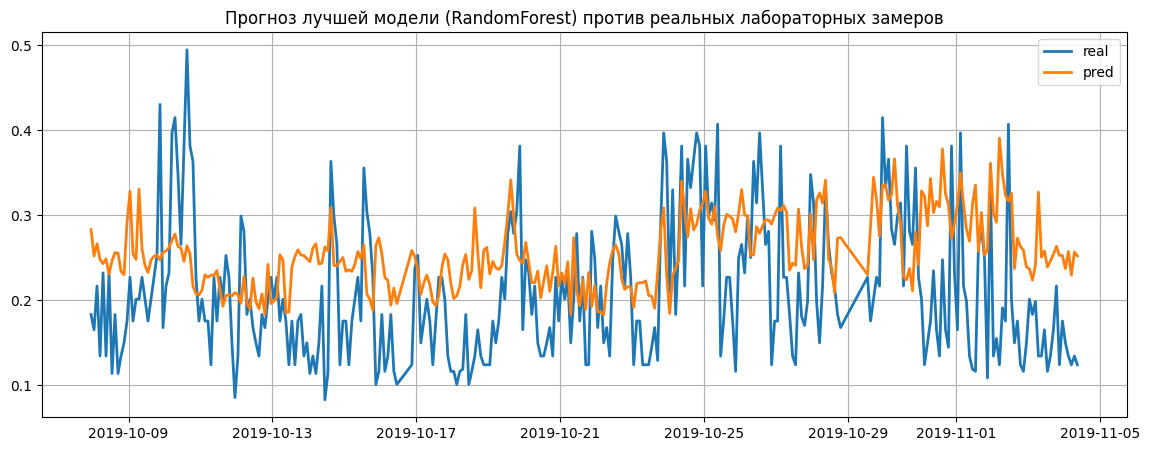

In [ ]:
test_time_col = "datetime_x" if "datetime_x" in test_supervised.columns else "datetime"

plt.figure(figsize=(14, 5))
plt.plot(test_supervised[test_time_col], y_test_holdout.values, label="real", linewidth=2)
plt.plot(test_supervised[test_time_col], best_test_pred, label="pred", linewidth=2)
plt.title(f"Прогноз лучшей модели ({best_model_name}) против реальных лабораторных замеров")
plt.legend()
plt.show()

,test,statistic,p_value
0,Jarque-Bera,14.103980,0.000866
1,Ljung-Box (lag=10),172.782747,0.000000


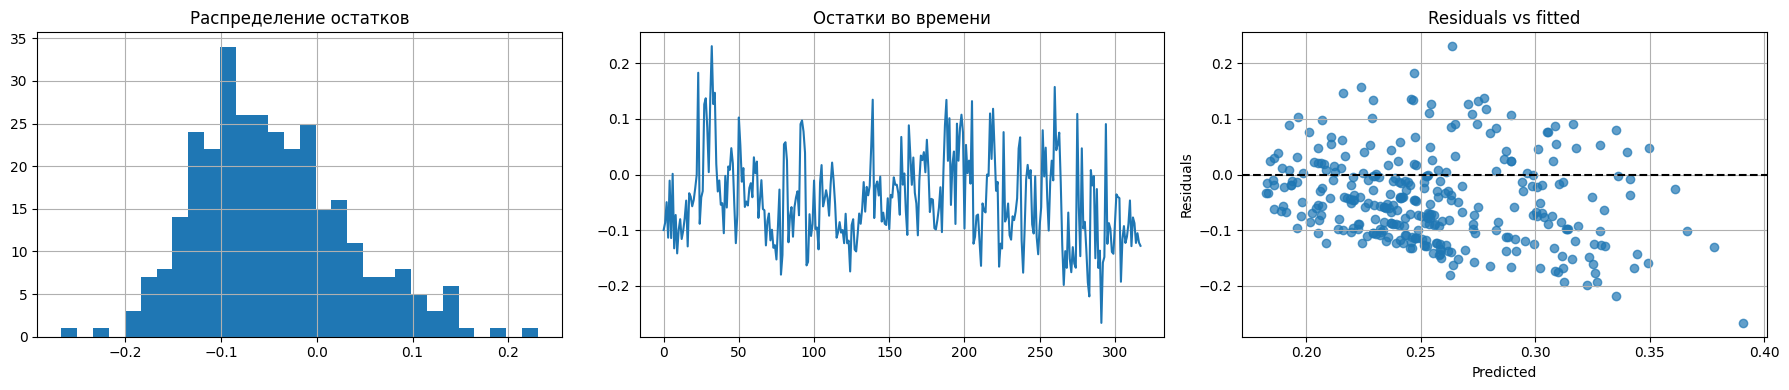

In [ ]:
diag_df, residuals = residual_diagnostics(y_test_holdout, best_test_pred)
display(diag_df.round(6))

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].hist(residuals, bins=30)
axes[0].set_title("Распределение остатков")

axes[1].plot(residuals)
axes[1].set_title("Остатки во времени")

axes[2].scatter(best_test_pred, residuals, alpha=0.7)
axes[2].axhline(0, color="black", linestyle="--")
axes[2].set_title("Residuals vs fitted")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Residuals")

plt.tight_layout()
plt.show()

In [ ]:
# Формальная проверка гетероскедастичности именно для OLS
X_valid_imp = ols_artifacts.imputer.transform(X_valid)
X_valid_sel = ols_artifacts.selector.transform(X_valid_imp)
X_valid_sel_df = pd.DataFrame(X_valid_sel, columns=ols_artifacts.selected_columns, index=X_valid.index)
X_valid_sel_df = sm.add_constant(X_valid_sel_df, has_constant="add")

ols_valid_residuals = y_valid - ols_valid_pred
bp_lm, bp_lm_pvalue, bp_fvalue, bp_f_pvalue = het_breuschpagan(ols_valid_residuals, X_valid_sel_df)

bp_result = pd.DataFrame([{
    "LM_stat": bp_lm,
    "LM_pvalue": bp_lm_pvalue,
    "F_stat": bp_fvalue,
    "F_pvalue": bp_f_pvalue
}])

display(bp_result.round(6))

,LM_stat,LM_pvalue,F_stat,F_pvalue
0,75.267142,0.000001,3.540934,0.0


В ходе выполнения лабораторной работы была решена задача построения виртуального датчика для оценки концентрации целевого продукта в текущий момент времени по данным минутной телеметрии печи. Был проведён разведочный анализ данных, в рамках которого исследованы структура временных рядов, пропуски, дубликаты, характер лабораторных измерений и особенности синхронизации двух источников данных. Установлено, что телеметрия является практически непрерывной, а лабораторные замеры целевой переменной поступают редко и нерегулярно, что подтверждает необходимость построения виртуального сенсора.

Для повышения качества прогноза были сформированы лаговые признаки, скользящие статистики, признаки динамики изменений и календарные признаки. Далее были обучены три модели: интерпретируемая статистическая модель OLS, ансамблевая модель RandomForestRegressor и бустинговая модель HistGradientBoostingRegressor. Модели были сравнены по метрикам MAE, RMSE, MAPE, WAPE, а также по способности корректно определять направление изменения целевого показателя.

Дополнительно был проведён анализ остатков и интерпретация значимости признаков. Полученные результаты показывают, что подход с использованием временных признаков и моделей машинного обучения позволяет построить работоспособный виртуальный датчик, способный оперативно оценивать качество процесса обжига между лабораторными измерениями. Такое решение может быть полезно для снижения риска запоздалой реакции оператора и повышения устойчивости технологического процесса.